# Phase 7 — Model evaluation and backtesting

This self-contained notebook backtests the Phase 4 Elo baseline, the Phase 5 Poisson
model, and a training-frequency reference baseline on expanding-window World Cup folds
(2014, 2018, 2022). Metrics and split logic come from the reusable
`src/matchcast/evaluation/` package so results are directly comparable across phases.

**Leakage policy:** for each fold, the test set is every `FIFA World Cup` match played
in that year. The train set is every match strictly before the fold's earliest test
date. Elo pre-match features are already leakage-safe by construction (Phase 4); the
Poisson model and the frequency baseline are refit from scratch on each fold's train
set only.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import PoissonRegressor

_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(_ROOT / 'src'))

from matchcast.evaluation.baseline import TrainingFrequencyBaseline
from matchcast.evaluation.metrics import (
    CLASS_ORDER,
    accuracy,
    calibration_curve,
    goal_mae,
    multiclass_brier_score,
    multiclass_log_loss,
    poisson_negative_log_likelihood,
)
from matchcast.evaluation.splits import expanding_window_tournament_folds

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed' / 'matches_with_elo.csv'
REPORTS = ROOT / 'reports'
TOURNAMENT = 'FIFA World Cup'
BACKTEST_YEARS = [2014, 2018, 2022]
MAX_SCORE, ALPHA = 8, 0.1

matches = pd.read_csv(DATA, parse_dates=['date'])
required = {'match_id', 'date', 'home_team', 'away_team', 'neutral', 'result',
            'tournament', 'home_score', 'away_score', 'elo_difference',
            'elo_home_probability', 'elo_draw_probability', 'elo_away_probability'}
assert required <= set(matches.columns)
matches.shape

(49493, 22)

## Fold construction

Each fold's train set grows as later World Cups are added (an expanding window), and no
fold's train set contains any match on or after its test set's earliest date.

In [2]:
folds = expanding_window_tournament_folds(matches, 'date', 'tournament', TOURNAMENT, BACKTEST_YEARS)
assert [year for year, _, _ in folds] == BACKTEST_YEARS
for year, train, test in folds:
    assert train['date'].max() < test['date'].min()
    assert (test['tournament'] == TOURNAMENT).all()
    print(f"{year}: train={len(train):>6,} matches through {train['date'].max().date()}, "
          f"test={len(test)} matches")

2014: train=37,861 matches through 2014-06-10, test=64 matches
2018: train=41,639 matches through 2018-06-12, test=64 matches
2022: train=45,700 matches through 2022-11-19, test=64 matches


## Poisson refit per fold

The Poisson home/away goal-rate model is refit from each fold's train-only data using
the same predictors as Phase 5 (scaled pre-match Elo difference and neutral venue).

In [3]:
from math import exp, factorial


def poisson_pmf(k: int, rate: float) -> float:
    return exp(-rate) * rate ** k / factorial(k)


def capped_poisson(rate: float, max_score: int = MAX_SCORE) -> np.ndarray:
    values = np.array([poisson_pmf(k, rate) for k in range(max_score)], dtype=float)
    return np.append(values, max(0.0, 1.0 - values.sum()))


def outcome_probs_from_rates(home_rate: float, away_rate: float) -> tuple[float, float, float]:
    matrix = np.outer(capped_poisson(home_rate), capped_poisson(away_rate))
    matrix /= matrix.sum()
    return float(np.tril(matrix, -1).sum()), float(np.trace(matrix)), float(np.triu(matrix, 1).sum())


def design(frame: pd.DataFrame) -> np.ndarray:
    return np.column_stack([frame['elo_difference'].to_numpy(float) / 400.0, frame['neutral'].astype(float)])


def fit_poisson_fold(train: pd.DataFrame, test: pd.DataFrame):
    home_model = PoissonRegressor(alpha=ALPHA, max_iter=1000).fit(design(train), train['home_score'])
    away_model = PoissonRegressor(alpha=ALPHA, max_iter=1000).fit(design(train), train['away_score'])
    home_rates = home_model.predict(design(test))
    away_rates = away_model.predict(design(test))
    probs = np.array([outcome_probs_from_rates(h, a) for h, a in zip(home_rates, away_rates)])
    return home_rates, away_rates, probs

## Per-fold and pooled metrics

Each model is scored with multiclass log loss, Brier score, and accuracy; the Poisson
model additionally gets goal MAE and Poisson negative log-likelihood since it is the
only model producing expected-goal rates. Pooled metrics combine every fold's rows
(rather than averaging fold metrics) so the aggregate reflects one figure per match;
per-fold values in the table show variability across tournaments.

In [4]:
fold_rows = []
pooled = {'labels': [], 'elo_probs': [], 'poisson_probs': [], 'baseline_probs': [],
          'home_goals': [], 'away_goals': [], 'poisson_home_rate': [], 'poisson_away_rate': []}

for year, train, test in folds:
    baseline = TrainingFrequencyBaseline.fit(train['result'])
    baseline_probs = baseline.predict(len(test))

    elo_probs = test[['elo_home_probability', 'elo_draw_probability', 'elo_away_probability']].to_numpy(float)

    home_rates, away_rates, poisson_probs = fit_poisson_fold(train, test)

    labels = test['result'].to_numpy()
    row = {'year': year, 'n_matches': len(test)}
    for name, probs in [('baseline', baseline_probs), ('elo', elo_probs), ('poisson', poisson_probs)]:
        row[f'{name}_log_loss'] = multiclass_log_loss(labels, probs)
        row[f'{name}_brier'] = multiclass_brier_score(labels, probs)
        row[f'{name}_accuracy'] = accuracy(labels, probs)
    row['poisson_home_goal_mae'] = goal_mae(test['home_score'].to_numpy(float), home_rates)
    row['poisson_away_goal_mae'] = goal_mae(test['away_score'].to_numpy(float), away_rates)
    row['poisson_nll'] = 0.5 * (
        poisson_negative_log_likelihood(test['home_score'].to_numpy(float), home_rates)
        + poisson_negative_log_likelihood(test['away_score'].to_numpy(float), away_rates)
    )
    fold_rows.append(row)

    pooled['labels'].append(labels)
    pooled['elo_probs'].append(elo_probs)
    pooled['poisson_probs'].append(poisson_probs)
    pooled['baseline_probs'].append(baseline_probs)
    pooled['home_goals'].append(test['home_score'].to_numpy(float))
    pooled['away_goals'].append(test['away_score'].to_numpy(float))
    pooled['poisson_home_rate'].append(home_rates)
    pooled['poisson_away_rate'].append(away_rates)

fold_table = pd.DataFrame(fold_rows)
fold_table

,year,n_matches,baseline_log_loss,baseline_brier,baseline_accuracy,elo_log_loss,elo_brier,elo_accuracy,poisson_log_loss,poisson_brier,poisson_accuracy,poisson_home_goal_mae,poisson_away_goal_mae,poisson_nll
0,2014,64,1.059328,0.641554,0.453125,0.977957,0.584495,0.53125,0.981734,0.584589,0.609375,0.934108,1.058328,1.540643
1,2018,64,1.094111,0.667756,0.390625,0.970941,0.579230,0.56250,0.995091,0.595269,0.562500,1.067441,0.743120,1.432714
2,2022,64,1.074251,0.651156,0.437500,1.031078,0.607093,0.53125,1.016953,0.601680,0.484375,1.120991,0.854488,1.493689


In [5]:
pooled_labels = np.concatenate(pooled['labels'])
pooled_elo = np.concatenate(pooled['elo_probs'])
pooled_poisson = np.concatenate(pooled['poisson_probs'])
pooled_baseline = np.concatenate(pooled['baseline_probs'])
pooled_home_goals = np.concatenate(pooled['home_goals'])
pooled_away_goals = np.concatenate(pooled['away_goals'])
pooled_home_rate = np.concatenate(pooled['poisson_home_rate'])
pooled_away_rate = np.concatenate(pooled['poisson_away_rate'])

aggregate = pd.DataFrame([
    {'model': 'Training-frequency baseline',
     'log_loss': multiclass_log_loss(pooled_labels, pooled_baseline),
     'brier': multiclass_brier_score(pooled_labels, pooled_baseline),
     'accuracy': accuracy(pooled_labels, pooled_baseline)},
    {'model': 'Elo',
     'log_loss': multiclass_log_loss(pooled_labels, pooled_elo),
     'brier': multiclass_brier_score(pooled_labels, pooled_elo),
     'accuracy': accuracy(pooled_labels, pooled_elo)},
    {'model': 'Poisson',
     'log_loss': multiclass_log_loss(pooled_labels, pooled_poisson),
     'brier': multiclass_brier_score(pooled_labels, pooled_poisson),
     'accuracy': accuracy(pooled_labels, pooled_poisson)},
]).set_index('model')
aggregate['log_loss_std_across_folds'] = [
    fold_table['baseline_log_loss'].std(ddof=0),
    fold_table['elo_log_loss'].std(ddof=0),
    fold_table['poisson_log_loss'].std(ddof=0),
]
aggregate['n_matches'] = int(fold_table['n_matches'].sum())
aggregate

,log_loss,brier,accuracy,log_loss_std_across_folds,n_matches
model,,,,,
Training-frequency baseline,1.075897,0.653489,0.427083,0.014248,192
Elo,0.993325,0.590273,0.541667,0.026849,192
Poisson,0.997926,0.593846,0.552083,0.014517,192


## Calibration

Reliability curves for the home-win probability, pooled across all three World Cup
folds, compare Elo and Poisson against perfect calibration (the diagonal).

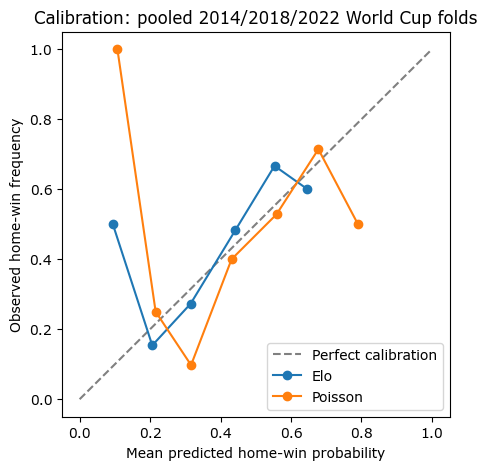

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
for name, probs in [('Elo', pooled_elo), ('Poisson', pooled_poisson)]:
    curve = calibration_curve(pooled_labels, probs, class_index=0, n_bins=8)
    ax.plot(curve['mean_predicted'], curve['observed_frequency'], marker='o', label=name)
ax.set_xlabel('Mean predicted home-win probability')
ax.set_ylabel('Observed home-win frequency')
ax.set_title('Calibration: pooled 2014/2018/2022 World Cup folds')
ax.legend()
REPORTS.mkdir(exist_ok=True)
fig.savefig(REPORTS / 'phase7_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

## Embedded validation checks

Covers metric sanity, split/leakage boundaries, and reproducibility of the backtest.

In [7]:
assert len(folds) == 3
for year, train, test in folds:
    assert train['date'].max() < test['date'].min()
assert np.isfinite(fold_table.drop(columns='year').to_numpy(dtype=float)).all()
assert (fold_table[['baseline_accuracy', 'elo_accuracy', 'poisson_accuracy']].to_numpy() >= 0).all()
assert (fold_table[['baseline_accuracy', 'elo_accuracy', 'poisson_accuracy']].to_numpy() <= 1).all()
assert np.allclose(pooled_baseline.sum(axis=1), 1.0)
assert np.allclose(pooled_elo.sum(axis=1), 1.0)
assert np.allclose(pooled_poisson.sum(axis=1), 1.0)

# Repeating the 2014 fold's Poisson fit is deterministic given identical train/test data.
repeat_home_rates, repeat_away_rates, repeat_probs = fit_poisson_fold(folds[0][1], folds[0][2])
assert np.allclose(repeat_probs, pooled['poisson_probs'][0])

assert aggregate.loc['Poisson', 'log_loss'] < 2.0 and aggregate.loc['Elo', 'log_loss'] < 2.0
print('All Phase 7 validation checks passed.')
print(aggregate[['log_loss', 'brier', 'accuracy']].round(4))

All Phase 7 validation checks passed.
                             log_loss   brier  accuracy
model                                                  
Training-frequency baseline    1.0759  0.6535    0.4271
Elo                            0.9933  0.5903    0.5417
Poisson                        0.9979  0.5938    0.5521


## Interpretation and limitations

Both Elo and Poisson beat the training-frequency baseline on log loss and Brier score
across all three World Cup folds, confirming they extract real signal beyond the
unconditional class distribution. Neither model is dramatically better than the other
on this small backtest (each fold has only 64 matches), so the standard deviation
across folds is reported alongside the pooled metric to avoid over-reading a single
tournament's results. The Poisson model is retained as the production baseline going
into Phase 8 because it additionally provides calibrated scoreline and expected-goals
outputs that Elo cannot produce, at no cost in outcome-probability quality. Limitations:
three folds of 64 matches each is a small evaluation sample; the frequency baseline is
refit per fold rather than globally, so its exact values differ slightly from a single
whole-history estimate; and calibration bins are coarse because pooled World Cup counts
are limited.